<a href="https://colab.research.google.com/github/Hashi-Muthu/Assignment-02-_-IT5437/blob/main/Q2.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

IT5437 - Assignment 2 -

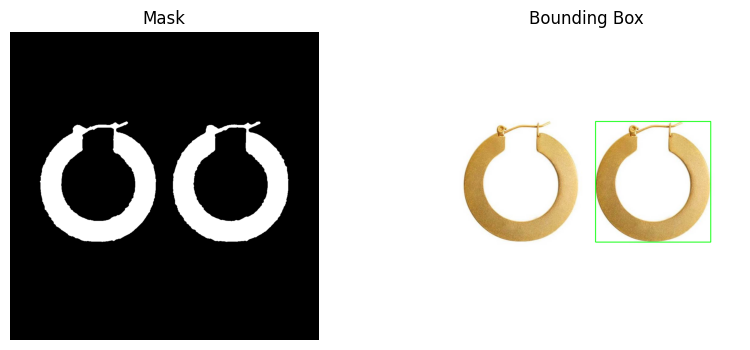

Width (pixels): 383
Height (pixels): 401
Real Width (mm): 75.834
Real Height (mm): 79.39800000000001


In [ ]:
import cv2 as cv
import numpy as np
import matplotlib.pyplot as plt

img = cv.imread("earrings.jpg")
assert img is not None

#  1) Create mask of object (white background assumption)
gray = cv.cvtColor(img, cv.COLOR_BGR2GRAY)

# Anything NOT near-white is considered object
# Tune 240–250 depending on your image
_, mask = cv.threshold(gray, 245, 255, cv.THRESH_BINARY_INV)

# 2) Morphology to connect thin parts (hook) 
kernel = cv.getStructuringElement(cv.MORPH_ELLIPSE, (7,7))
mask = cv.morphologyEx(mask, cv.MORPH_CLOSE, kernel, iterations=2)  # connect gaps
mask = cv.morphologyEx(mask, cv.MORPH_OPEN,  kernel, iterations=1)  # remove specks

# Optional: fill holes inside the ring
contours, _ = cv.findContours(mask, cv.RETR_EXTERNAL, cv.CHAIN_APPROX_SIMPLE)
cnt = max(contours, key=cv.contourArea)

# 3) Bounding box on the FULL object contour 
x, y, w, h = cv.boundingRect(cnt)

output = img.copy()
cv.rectangle(output, (x,y), (x+w, y+h), (0,255,0), 2)

plt.figure(figsize=(10,4))
plt.subplot(1,2,1); plt.imshow(mask, cmap="gray"); plt.title("Mask"); plt.axis("off")
plt.subplot(1,2,2); plt.imshow(cv.cvtColor(output, cv.COLOR_BGR2RGB)); plt.title("Bounding Box"); plt.axis("off")
plt.show()

print("Width (pixels):", w)
print("Height (pixels):", h)

# 10. Convert to real-world size
pixel_size_mm = 2.2e-3   # 2.2 micrometers
f = 8                    # focal length (mm)
D = 720                  # distance (mm)

m = f / D

width_mm = (w * pixel_size_mm) / m
height_mm = (h * pixel_size_mm) / m

print("Real Width (mm):", width_mm)
print("Real Height (mm):", height_mm)